
# IND320 — Project work, part 1

## Lenker
- GitHub-repo: https://github.com/malikaaebo-cell/IND320_prosjekt
- Streamlit-app: https://malikaaebo-cell-ind320-prosjekt-main-rqsvdg.streamlit.app

## AI-bruk

Jeg har brukt Claude som støtte gjennom arbeidet med denne innleveringen. Konkret har jeg fått hjelp til feilsøking av tekniske problemer underveis, blant annet en korrupt plotly-installasjon, en diskplass-feil som hindret pakkeinstallasjon, og en vedvarende korrupsjon i det virtuelle miljøet som til slutt ble løst ved å bygge miljøet på nytt fra bunnen. Jeg har også fått generell veiledning i VS Code, som kernel-valg, virtuelle miljøer og Jupyter Notebook-oppsett, samt hjelp til å tolke eksempelkoder fra kildene mine, som kursmateriale, offisiell dokumentasjon og eksempel-repoer. All kode er gjennomgått og forstått av meg selv før den ble tatt i bruk.

## Logg

Arbeidet med denne innleveringen startet med å sette opp en GitHub-konto og et offentlig repository, koblet til en Streamlit-app for å oppfylle kravet om et minimum working example. Jeg brukte først en øvingsoppgave (en Collatz-formodning-app) til å lære grunnleggende Streamlit-konsepter som session_state og betinget logikk, samt selve arbeidsflyten mellom VS Code, Git og Streamlit Community Cloud. Siden dette arbeidet opprinnelig lå i samme mappe som kursmaterialet, flyttet jeg senere prosjektet til et eget, rent repository for å holde innleveringen ryddig.

I Jupyter Notebook leste jeg inn reservoirs.csv med pandas, og omdøpte kolonnenavnene fra norsk til forståelig engelsk med rename(). Jeg brukte info() og describe() for å få oversikt over datasettet, som avdekket at kolonnene har svært ulike verdiområder, og at enkelte kolonner (som dato-feltene) ble lest inn som tekst i stedet for datotype. Jeg plottet deretter hver numeriske kolonne separat med matplotlib, og oppdaget at dataene ikke var sortert kronologisk, noe som ga kaotiske plott. Da jeg plottet alle kolonnene sammen, sorterte jeg derfor datasettet på dato og normaliserte verdiene til samme skala, noe som avslørte et tydelig, repeterende sesongmønster i magasinfyllingen.

Streamlit-appen består av fem sider. Main (forsiden, med automatisk sidebar-navigasjon), tabell, plot, side3 og side4. Tabell-siden viser en tabell der hver rad representerer én kolonne fra datasettet, med en radvis LineChartColumn som viser trenden for datasettets første måned. Plot-siden viser et plot med en nedtrekksmeny for å velge én eller alle kolonner, og en periodevelger for å filtrere tidsrommet, med caching for raskere lasting. Side3 og side4 inneholder foreløpig kun placeholder-innhold, i tråd med oppgavens krav om dummy-innhold for disse to sidene.

Underveis møtte jeg flere tekniske utfordringer, særlig knyttet til et virtuelt miljø som gradvis ble korrupt etter en diskplass-feil under installasjon av kursets fulle pakkeliste. Dette viste seg som en rekke ulike feilmeldinger for forskjellige biblioteker over flere økter, og ble til slutt løst ved å bygge det virtuelle miljøet helt på nytt og kun installere de pakkene prosjektet faktisk trenger.

I tillegg har jeg brukt claude til å hjelpe meg med å strukturere kildeliste, slik at den blir mer oversiktlig.

## Kilder

- **Organisering av prosjektmappen:** brukt som mal for hvordan et Streamlit-prosjekt kan struktureres med egne mapper for sider (pages/), delt kode (modules/) og notebook (notebooks/), siden oppgaveteksten ikke spesifiserer en konkret struktur. Kilde: [github.com/khliland/ind320_student](https://github.com/khliland/ind320_student)
- **Enkel tekstvisning på sidene:** inspirert av blank_canvas.py (kurseksempel) — brukt for tittel og beskrivende tekst øverst på hver side i appen.
- **Rask innlasting av data i appen:** inspirert av caching.py (kurseksempel) — brukt for å unngå at CSV-filen leses på nytt ved hver interaksjon, som oppgaven krever for hastighet.
- **Publisering av appen på nett:** fulgt fra 4_Streamlit.ipynb (kursnotebook) for å koble GitHub-repoet til Streamlit Community Cloud og få appen til å kjøre på en offentlig URL.
- **Oversettelse av kolonnenavn til engelsk:** brukt for å gi de norske kolonnenavnene i reservoirs.csv forståelige engelske navn, som oppgaven krever. Kilde: [Pandas-dokumentasjon for rename()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)
- **Filtrering til kun tallkolonner før plotting:** brukt for å automatisk hoppe over tekstkolonner (som dato) ved plotting, slik at de ikke gir feil. Kilde: [Pandas-dokumentasjon for select_dtypes()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html)
- **Plotting av datasettet:** brukt som grunnlag for å plotte hver kolonne separat og alle kolonner sammen i notebooken. Kilde: [Matplotlib pyplot-eksempel](https://matplotlib.org/stable/gallery/pyplots/pyplot_simple.html)
- **Minigraf per rad i tabellen:** brukt for å vise en trendlinje for hver kolonne på tabell-siden, som oppgaven eksplisitt ber om. Kilde: [Streamlit-dokumentasjon for LineChartColumn](https://docs.streamlit.io/develop/api-reference/data/st.column_config/st.column_config.linechartcolumn)
- **Valg av tidsrom i plottet:** brukt til å la brukeren velge måneder å vise i plot-siden, siden dette widget-et ikke ble dekket i kurset. Kilde: [Streamlit-dokumentasjon for select_slider](https://docs.streamlit.io/develop/api-reference/widgets/st.select_slider)
- **Gruppering av datoer til måneder:** brukt for å gjøre periodevelgeren månedsbasert i stedet for å vise hver enkelt dato. Kilde: [Pandas-dokumentasjon for dt.to_period()](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html)


In [ ]:
import pandas as pd

# Leser inn dataene
df = pd.read_csv('../project_data/reservoirs.csv')

# For å se opprinnelige kolonnenavn
print(df.columns.tolist())


['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad', 'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato', 'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad']


In [3]:
# Gi kolonnene forståelige, engelske navn
df = df.rename(columns={
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'fill_ratio',
    'kapasitet_TWh': 'capacity_twh',
    'fylling_TWh': 'fill_twh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'fill_ratio_previous_week',
    'endring_fyllingsgrad': 'fill_ratio_change'
})

df.head()

,date,area_type,area_number,iso_year,iso_week,fill_ratio,capacity_twh,fill_twh,next_publication_date,fill_ratio_previous_week,fill_ratio_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [4]:
# Grunnleggende oversikt over dataene
print(f"Antall rader: {df.shape[0]}")
print(f"Antall kolonner: {df.shape[1]}")
print()
df.info()

Antall rader: 14877
Antall kolonner: 11

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      14877 non-null  str    
 1   area_type                 14877 non-null  str    
 2   area_number               14877 non-null  int64  
 3   iso_year                  14877 non-null  int64  
 4   iso_week                  14877 non-null  int64  
 5   fill_ratio                14877 non-null  float64
 6   capacity_twh              14877 non-null  float64
 7   fill_twh                  14877 non-null  float64
 8   next_publication_date     14877 non-null  str    
 9   fill_ratio_previous_week  14877 non-null  float64
 10  fill_ratio_change         14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.2 MB


In [5]:
df.describe()

,area_number,iso_year,iso_week,fill_ratio,capacity_twh,fill_twh,fill_ratio_previous_week,fill_ratio_change
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
std,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623


Matplotlib is building the font cache; this may take a moment.


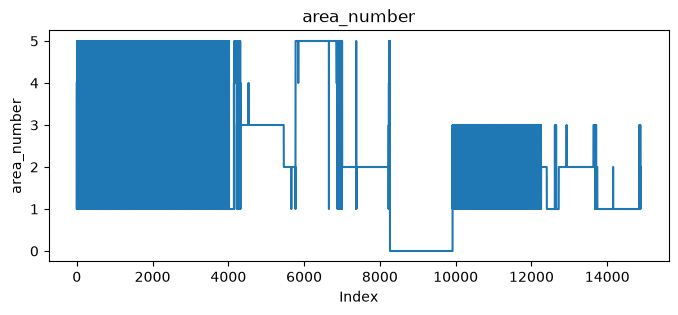

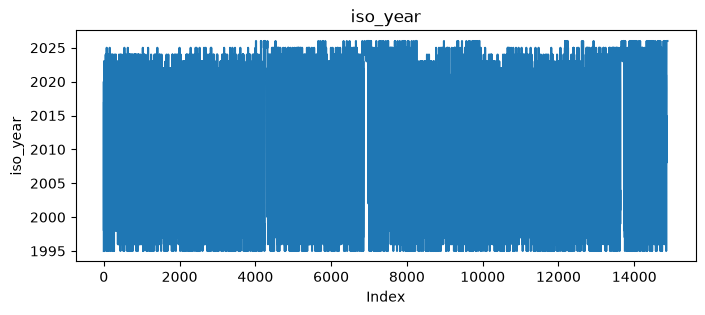

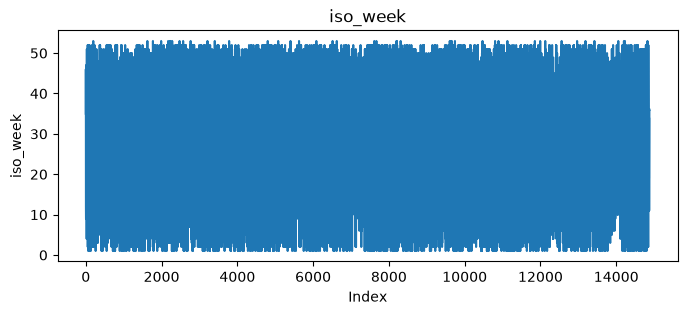

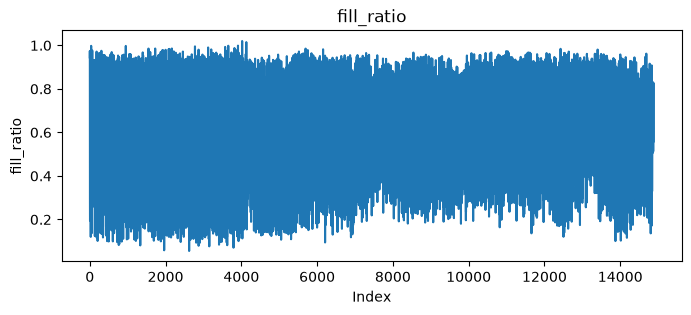

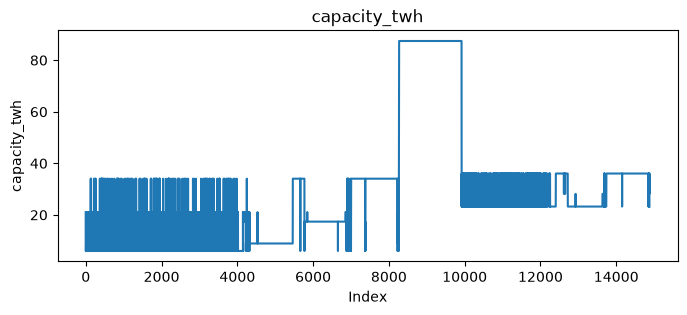

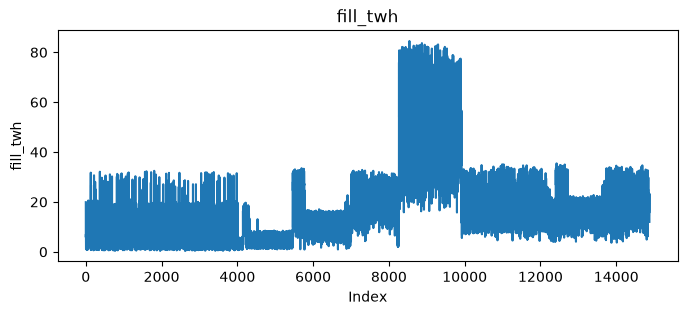

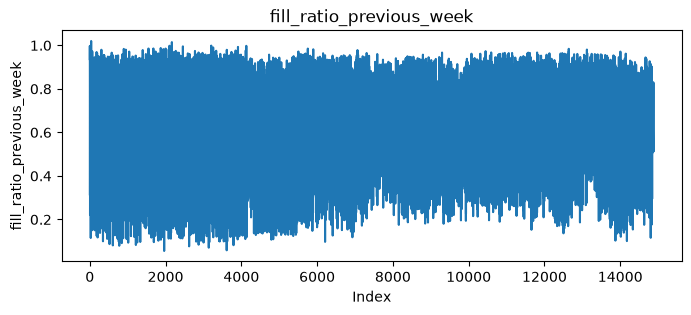

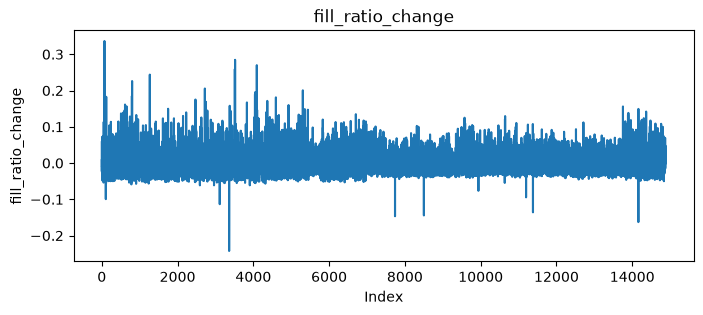

In [7]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    plt.plot(df[col])
    plt.title(col)
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.show()

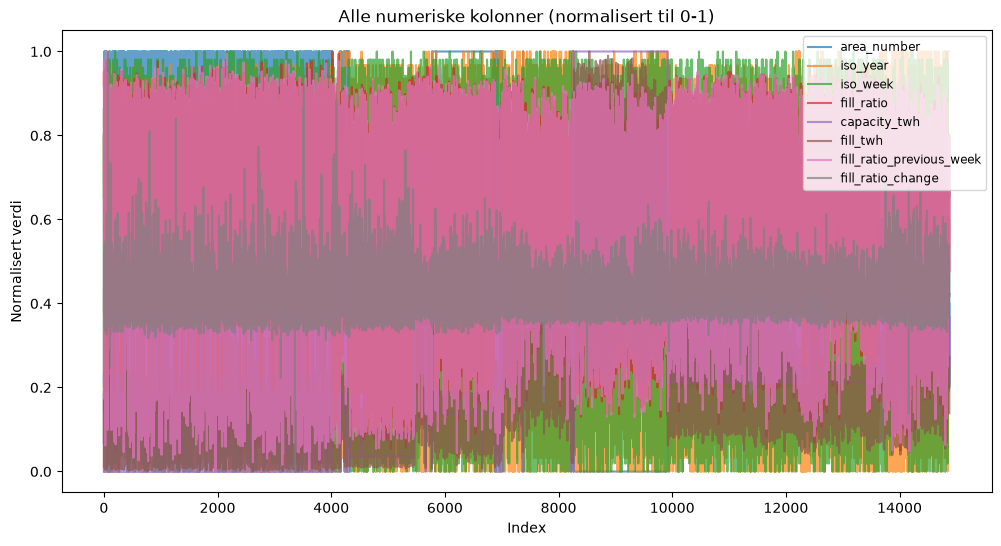

In [ ]:
# Skal normalisere hver numerisk kolonne til 0-1 for å kunne sammenligne dem i samme plot, forsøk 1
normalized = (df[numeric_cols] - df[numeric_cols].min()) / (df[numeric_cols].max() - df[numeric_cols].min())

plt.figure(figsize=(12, 6))
for col in numeric_cols:
    plt.plot(normalized[col], label=col, alpha=0.7)

plt.title('Alle numeriske kolonner (normalisert til 0-1)')
plt.xlabel('Index')
plt.ylabel('Normalisert verdi')
plt.legend(loc='upper right', fontsize='small')
plt.show()

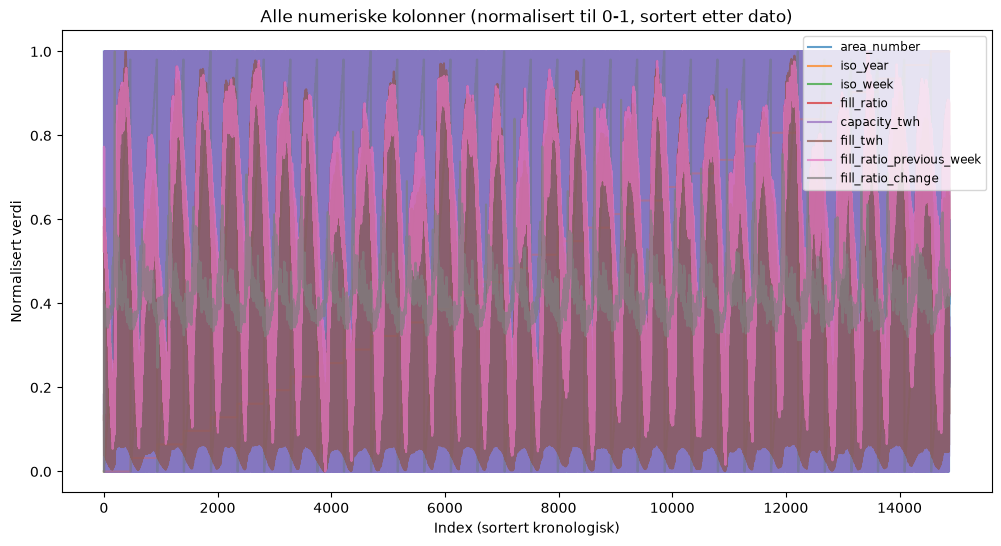

In [ ]:
# Sorter etter dato for et mer naturlig, lesbart tidsserieplot, forsøk 2
df_sorted = df.sort_values('date')

normalized_sorted = (df_sorted[numeric_cols] - df_sorted[numeric_cols].min()) / (df_sorted[numeric_cols].max() - df_sorted[numeric_cols].min())

plt.figure(figsize=(12, 6))
for col in numeric_cols:
    plt.plot(normalized_sorted[col].values, label=col, alpha=0.7)

plt.title('Alle numeriske kolonner (normalisert til 0-1, sortert etter dato)')
plt.xlabel('Index (sortert kronologisk)')
plt.ylabel('Normalisert verdi')
plt.legend(loc='upper right', fontsize='small')
plt.show()